In [1]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

print("--- Training Data Types ---")
print(train_df.dtypes)
print("\n--- Test Data Types ---")
print(test_df.dtypes)

print("\n--- Training Data Info ---")
print(train_df.info())

--- Training Data Types ---
id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
sentiment      int64
dtype: object

--- Test Data Types ---
id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
dtype: object

--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB
None


In [3]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

num_cols = ['feature_1', 'feature_2', 'feature_3']

print("--- Training Set: Numerical Descriptive Statistics ---")
print(train_df[num_cols + ['sentiment']].describe())

print("\n--- Training Set: Missing Values Count ---")
print(train_df[num_cols].isnull().sum())

print("\n" + "="*50 + "\n")

print("--- Test Set: Numerical Descriptive Statistics ---")
print(test_df[num_cols].describe())

print("\n--- Test Set: Missing Values Count ---")
print(test_df[num_cols].isnull().sum())

--- Training Set: Numerical Descriptive Statistics ---
         feature_1    feature_2    feature_3    sentiment
count  6088.000000  5896.000000  5938.000000  7000.000000
mean     19.025624     1.996608     3.334119     1.041143
std       9.303562     1.634858     2.321154     0.898010
min       1.000000     0.000000     0.000000     0.000000
25%      12.000000     1.000000     2.000000     0.000000
50%      18.000000     1.000000     3.000000     1.000000
75%      25.000000     3.000000     4.000000     2.000000
max      52.000000    19.000000    19.000000     2.000000

--- Training Set: Missing Values Count ---
feature_1     912
feature_2    1104
feature_3    1062
dtype: int64


--- Test Set: Numerical Descriptive Statistics ---
         feature_1    feature_2    feature_3
count  1478.000000  1382.000000  1610.000000
mean     19.029093     1.984805     3.449689
std       9.203255     1.589858     2.531888
min       2.000000     0.000000     0.000000
25%      12.000000     1.000000   

In [4]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

print("Missing values before handling (Train):")
print(train_df.isnull().sum())

num_cols = ['feature_1', 'feature_2', 'feature_3']
for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())
    test_df[col] = test_df[col].fillna(test_df[col].median())

train_df['phrase'] = train_df['phrase'].fillna('')
test_df['phrase'] = test_df['phrase'].fillna('')

print("\nMissing values after handling (Train):")
print(train_df.isnull().sum())

train_df.to_csv('train_cleaned.csv', index=False)
test_df.to_csv('test_cleaned.csv', index=False)

Missing values before handling (Train):
id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

Missing values after handling (Train):
id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
sentiment    0
dtype: int64


In [5]:
import pandas as pd

train_df = pd.read_csv('/kaggle/working/train_cleaned.csv')
test_df = pd.read_csv('/kaggle/working/test_cleaned.csv')

exact_dupes = train_df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

phrase_dupes = train_df.duplicated(subset=['phrase']).sum()
print(f"Duplicate 'phrase' entries: {phrase_dupes}")

train_df = train_df.drop_duplicates(subset=['phrase', 'sentiment'], keep='first')

print(f"\nFinal row count in Training Set: {len(train_df)}")

train_df.to_csv('train_cleaned.csv', index=False)

Exact duplicate rows: 0
Duplicate 'phrase' entries: 177

Final row count in Training Set: 6823


In [6]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('/kaggle/working/train_cleaned.csv')
test_df = pd.read_csv('/kaggle/working/test_cleaned.csv')

num_cols = ['feature_1', 'feature_2', 'feature_3']

def handle_outliers_iqr(df_in, columns, fit_df=None):
    df = df_in.copy()
    source_df = fit_df if fit_df is not None else df
    
    for col in columns:
        Q1 = source_df[col].quantile(0.25)
        Q3 = source_df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        print(f"Column '{col}': Capping {outlier_count} values outside [{lower_bound}, {upper_bound}]")
        
        df[col] = np.where(df[col] < lower_bound, lower_bound, 
                  np.where(df[col] > upper_bound, upper_bound, df[col]))
    return df

print("--- Handling Outliers in Train ---")
train_df = handle_outliers_iqr(train_df, num_cols)

print("\n--- Handling Outliers in Test ---")
test_df = handle_outliers_iqr(test_df, num_cols, fit_df=pd.read_csv('train_cleaned.csv'))

train_df.to_csv('train_milestone_5.csv', index=False)
test_df.to_csv('test_milestone_5.csv', index=False)

--- Handling Outliers in Train ---
Column 'feature_1': Capping 117 values outside [-3.5, 40.5]
Column 'feature_2': Capping 826 values outside [-0.5, 3.5]
Column 'feature_3': Capping 323 values outside [-1.0, 7.0]

--- Handling Outliers in Test ---
Column 'feature_1': Capping 24 values outside [-3.5, 40.5]
Column 'feature_2': Capping 195 values outside [-0.5, 3.5]
Column 'feature_3': Capping 118 values outside [-1.0, 7.0]


--- Milestone 1: Column Data Types ---
id             int64
phrase        object
feature_1    float64
feature_2    float64
feature_3    float64
sentiment      int64
dtype: object

--- Milestone 2: Descriptive Statistics ---
         feature_1    feature_2    feature_3    sentiment
count  6088.000000  5896.000000  5938.000000  7000.000000
mean     19.025624     1.996608     3.334119     1.041143
std       9.303562     1.634858     2.321154     0.898010
min       1.000000     0.000000     0.000000     0.000000
25%      12.000000     1.000000     2.000000     0.000000
50%      18.000000     1.000000     3.000000     1.000000
75%      25.000000     3.000000     4.000000     2.000000
max      52.000000    19.000000    19.000000     2.000000

--- Milestone 3: Missing Values Handled ---

--- Milestone 4: Duplicates Handled. Rows remaining: 6823 ---

--- Milestone 5: Outliers Capped (Winsorization) ---

--- Milestone 6: Generating Visualizations ---


/tmp/ipykernel_55/2838703087.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=train_df, palette='viridis')
/tmp/ipykernel_55/2838703087.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='feature_1', data=train_df, palette='Set2')


All plots saved as PNG files.


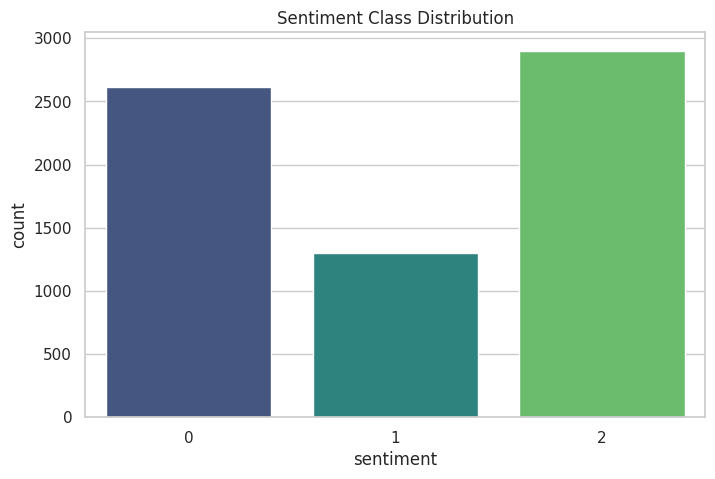

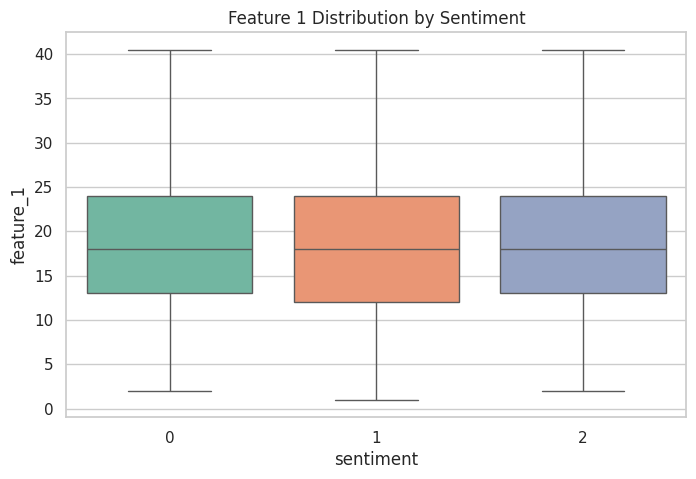

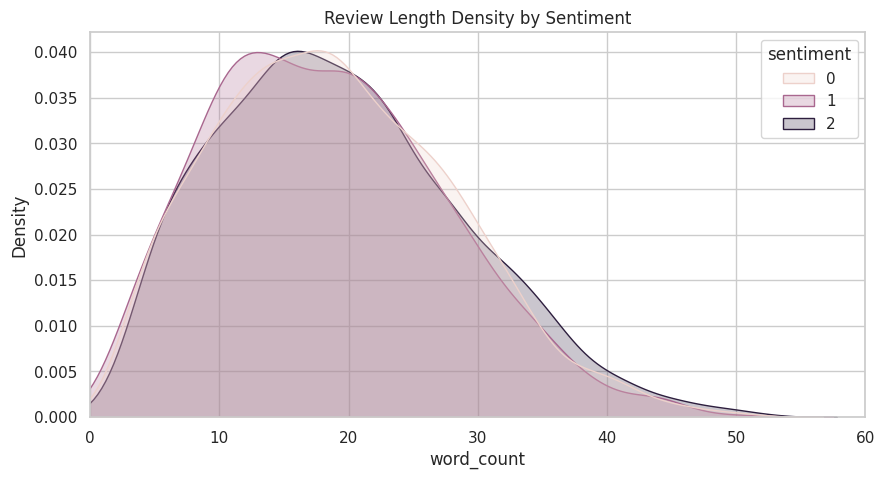

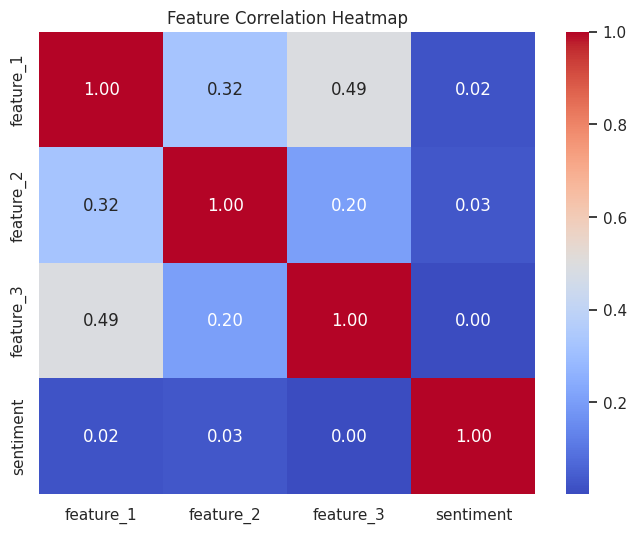

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

train_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

print("--- Milestone 1: Column Data Types ---")
print(train_df.dtypes)

print("\n--- Milestone 2: Descriptive Statistics ---")
num_cols = ['feature_1', 'feature_2', 'feature_3']
print(train_df[num_cols + ['sentiment']].describe())

for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())
    test_df[col] = test_df[col].fillna(test_df[col].median())

train_df['phrase'] = train_df['phrase'].fillna('')
test_df['phrase'] = test_df['phrase'].fillna('')

print("\n--- Milestone 3: Missing Values Handled ---")

train_df = train_df.drop_duplicates(subset=['phrase', 'sentiment'], keep='first')
print(f"\n--- Milestone 4: Duplicates Handled. Rows remaining: {len(train_df)} ---")

def handle_outliers_iqr(df, columns):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, 
                         np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col]))
    return df_capped

train_df = handle_outliers_iqr(train_df, num_cols)
test_df = handle_outliers_iqr(test_df, num_cols)
print("\n--- Milestone 5: Outliers Capped (Winsorization) ---")

print("\n--- Milestone 6: Generating Visualizations ---")

plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=train_df, palette='viridis')
plt.title('Sentiment Class Distribution')
plt.savefig('sentiment_dist.png')

plt.figure(figsize=(8, 5))
sns.boxplot(x='sentiment', y='feature_1', data=train_df, palette='Set2')
plt.title('Feature 1 Distribution by Sentiment')
plt.savefig('feature1_boxplot.png')

train_df['word_count'] = train_df['phrase'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train_df, x='word_count', hue='sentiment', fill=True, common_norm=False)
plt.title('Review Length Density by Sentiment')
plt.xlim(0, 60)
plt.savefig('word_count_density.png')

plt.figure(figsize=(8, 6))
sns.heatmap(train_df[num_cols + ['sentiment']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

print("All plots saved as PNG files.")

train_df.to_csv('train_final_cleaned.csv', index=False)
test_df.to_csv('test_final_cleaned.csv', index=False)

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

train_df = pd.read_csv('/kaggle/working/train_final_cleaned.csv')
test_df = pd.read_csv('/kaggle/working/test_final_cleaned.csv')

num_cols = ['feature_1', 'feature_2', 'feature_3']

scaler = StandardScaler()

train_df[num_cols] = scaler.fit_transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

print("--- Numerical Features Scaled ---")

tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(train_df['phrase'])
X_test_tfidf = tfidf.transform(test_df['phrase'])

print(f"--- Text Encoded. TF-IDF Matrix Shape: {X_train_tfidf.shape} ---")

import scipy.sparse as sp

X_train_num = sp.csr_matrix(train_df[num_cols].values)
X_test_num = sp.csr_matrix(test_df[num_cols].values)

X_train_final = sp.hstack((X_train_num, X_train_tfidf))
X_test_final = sp.hstack((X_test_num, X_test_tfidf))

print(f"Final training feature set shape: {X_train_final.shape}")

y_train = train_df['sentiment']

--- Numerical Features Scaled ---
--- Text Encoded. TF-IDF Matrix Shape: (6823, 5000) ---
Final training feature set shape: (6823, 5003)


In [9]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

train_df = pd.read_csv('/kaggle/working/train_milestone_5.csv')

scaler = MinMaxScaler()
X_num = scaler.fit_transform(train_df[['feature_1', 'feature_2', 'feature_3']])

tfidf = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2))
X_text = tfidf.fit_transform(train_df['phrase'])

X = sp.hstack((sp.csr_matrix(X_num), X_text))
y = train_df['sentiment']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

model_performance = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    accuracy = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    model_performance.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1-Score": f1
    })

performance_df = pd.DataFrame(model_performance).sort_values(by='Accuracy', ascending=False)
print(performance_df)

                     Model  Accuracy  F1-Score
0  Multinomial Naive Bayes  0.627106  0.563009
1      Logistic Regression  0.618315  0.573657
2               Linear SVC  0.599267  0.583155
3            Random Forest  0.575824  0.545548
4            Decision Tree  0.485714  0.479475
5                 AdaBoost  0.453480  0.322003
6      K-Nearest Neighbors  0.319414  0.300971


In [10]:
from sklearn.model_selection import GridSearchCV

nb_params = {'alpha': [0.01, 0.1, 0.5, 1.0, 5.0]}

lr_params = {
    'C': [0.1, 1, 10], 
    'solver': ['lbfgs', 'liblinear']
}

svc_params = {'C': [0.01, 0.1, 1, 10]}

print("--- Tuning Multinomial Naive Bayes ---")
nb_grid = GridSearchCV(MultinomialNB(), nb_params, cv=3, scoring='accuracy')
nb_grid.fit(X, y)

print("--- Tuning Logistic Regression ---")
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=3, scoring='accuracy')
lr_grid.fit(X, y)

print("--- Tuning Linear SVC ---")
svc_grid = GridSearchCV(LinearSVC(random_state=42), svc_params, cv=3, scoring='accuracy')
svc_grid.fit(X, y)

tuning_summary = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression", "Linear SVC"],
    "Best Parameters": [nb_grid.best_params_, lr_grid.best_params_, svc_grid.best_params_],
    "CV Accuracy Score": [nb_grid.best_score_, lr_grid.best_score_, svc_grid.best_score_]
})

print(tuning_summary)

--- Tuning Multinomial Naive Bayes ---
--- Tuning Logistic Regression ---
--- Tuning Linear SVC ---
                     Model                  Best Parameters  CV Accuracy Score
0  Multinomial Naive Bayes                   {'alpha': 1.0}           0.607064
1      Logistic Regression  {'C': 1, 'solver': 'liblinear'}           0.602961
2               Linear SVC                       {'C': 0.1}           0.602228


--- Model Comparison Results ---
                     Model  Accuracy  F1-Score
0  Multinomial Naive Bayes  0.623443  0.562049
1      Logistic Regression  0.621245  0.578119
2               Linear SVC  0.581685  0.567018
3            Random Forest  0.576557  0.541444
4            Decision Tree  0.477656  0.471177
5                 AdaBoost  0.443956  0.293793
6              K-Neighbors  0.339194  0.312593

Comparison bar chart saved as 'model_comparison_bar.png'.


/tmp/ipykernel_55/2197190502.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=comparison_df, palette='viridis')


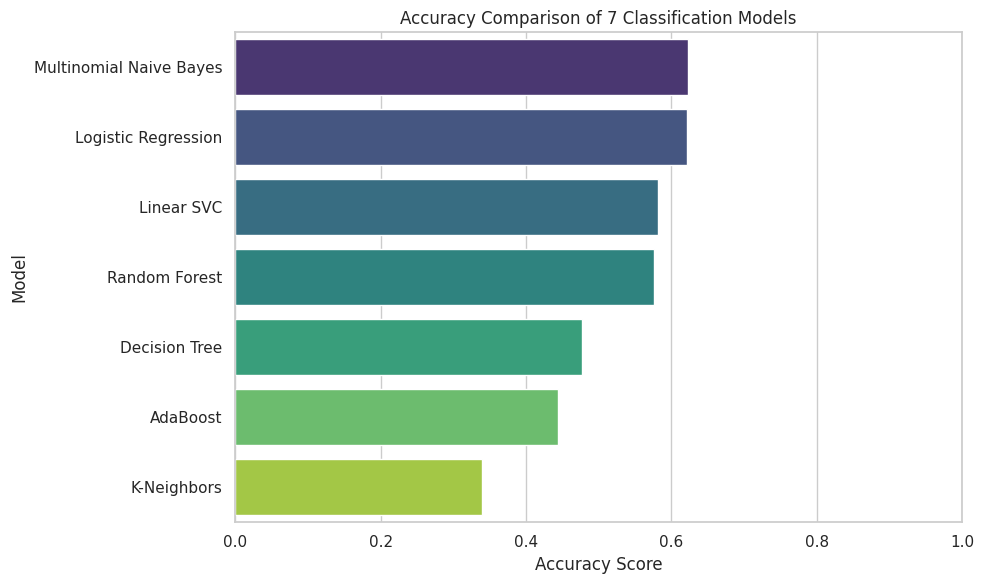

In [11]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

train_df = pd.read_csv('/kaggle/working/train_milestone_5.csv')

num_cols = ['feature_1', 'feature_2', 'feature_3']
scaler = MinMaxScaler()
X_num = scaler.fit_transform(train_df[num_cols])

tfidf = TfidfVectorizer(max_features=2500, stop_words='english', ngram_range=(1, 2))
X_text = tfidf.fit_transform(train_df['phrase'])

X = sp.hstack((sp.csr_matrix(X_num), X_text))
y = train_df['sentiment']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVC": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "K-Neighbors": KNeighborsClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

comparison_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("--- Model Comparison Results ---")
print(comparison_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=comparison_df, palette='viridis')
plt.title('Accuracy Comparison of 7 Classification Models')
plt.xlabel('Accuracy Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison_bar.png')

print("\nComparison bar chart saved as 'model_comparison_bar.png'.")

In [12]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB

train_df = pd.read_csv('/kaggle/working/train_milestone_5.csv')
test_df = pd.read_csv('/kaggle/working/test_milestone_5.csv')

num_cols = ['feature_1', 'feature_2', 'feature_3']
scaler = MinMaxScaler()

X_train_num = scaler.fit_transform(train_df[num_cols])
X_test_num = scaler.transform(test_df[num_cols])

tfidf = TfidfVectorizer(max_features=3000, stop_words='english', ngram_range=(1, 2))

X_train_text = tfidf.fit_transform(train_df['phrase'])
X_test_text = tfidf.transform(test_df['phrase'])

X_train_final = sp.hstack((sp.csr_matrix(X_train_num), X_train_text))
X_test_final = sp.hstack((sp.csr_matrix(X_test_num), X_test_text))
y_train = train_df['sentiment']

final_model = MultinomialNB(alpha=1.0)
final_model.fit(X_train_final, y_train)

test_predictions = final_model.predict(X_test_final)

submission = pd.DataFrame({
    'id': test_df['id'],
    'sentiment': test_predictions
})

submission.to_csv('submission.csv', index=False)

print("Final submission file 'submission.csv' has been generated successfully!")

Final submission file 'submission.csv' has been generated successfully!


In [13]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

train = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

num_cols = ['feature_1', 'feature_2', 'feature_3']
for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

def cap_outliers(df, columns):
    for col in columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = np.clip(df[col], Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return df

train = cap_outliers(train, num_cols)
test = cap_outliers(test, num_cols)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"[^a-z\s]", " ", text) 
    text = re.sub(r"\s+", " ", text).strip()
    return text

train['phrase_clean'] = train['phrase'].apply(clean_text)
test['phrase_clean'] = test['phrase'].apply(clean_text)

train['word_count'] = train['phrase'].apply(lambda x: len(str(x).split()))
test['word_count'] = test['phrase'].apply(lambda x: len(str(x).split()))
final_num_cols = num_cols + ['word_count']

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train[final_num_cols])
X_num_test = scaler.transform(test[final_num_cols])

tfidf = TfidfVectorizer(
    max_features=15000, 
    ngram_range=(1, 3), 
    stop_words='english',
    sublinear_tf=True 
)

X_text_train = tfidf.fit_transform(train['phrase_clean'])
X_text_test = tfidf.transform(test['phrase_clean'])

X_train = sp.hstack((sp.csr_matrix(X_num_train), X_text_train))
X_test = sp.hstack((sp.csr_matrix(X_num_test), X_text_test))
y_train = train['sentiment']

model = LogisticRegression(
    C=0.5, 
    max_iter=2000, 
    class_weight='balanced', 
    solver='liblinear',
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)
submission = pd.DataFrame({
    'id': test['id'],
    'sentiment': preds
})

submission.to_csv('submission.csv', index=False)
print("Final submission.csv saved. Ready for Kaggle upload!")

Final submission.csv saved. Ready for Kaggle upload!


In [14]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

train = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

def ultra_clean(text):
    text = str(text).lower()
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+[a-zA-Z]\s+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train['phrase'] = train['phrase'].apply(ultra_clean)
test['phrase'] = test['phrase'].apply(ultra_clean)

num_cols = ['feature_1', 'feature_2', 'feature_3']
for col in num_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(test[col].median())

tfidf = TfidfVectorizer(
    max_features=20000, 
    ngram_range=(1, 2), 
    sublinear_tf=True,
    min_df=2, 
    max_df=0.9
)

X_text_train = tfidf.fit_transform(train['phrase'])
X_text_test = tfidf.transform(test['phrase'])

num_scaler = MaxAbsScaler()
X_num_train = num_scaler.fit_transform(train[num_cols])
X_num_test = num_scaler.transform(test[num_cols])

X_train_final = sp.hstack((sp.csr_matrix(X_num_train), X_text_train))
X_test_final = sp.hstack((sp.csr_matrix(X_num_test), X_text_test))
y_train = train['sentiment']

svc = LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=3000)
lr = LogisticRegression(C=1.0, class_weight='balanced', solver='liblinear', random_state=42)

ensemble = VotingClassifier(
    estimators=[
        ('svc', CalibratedClassifierCV(svc, cv=3)),
        ('lr', lr)
    ],
    voting='soft',
    weights=[2, 1] 
)

print("Training final ensemble model...")
ensemble.fit(X_train_final, y_train)

test_preds = ensemble.predict(X_test_final)
submission = pd.DataFrame({
    'id': test['id'],
    'sentiment': test_preds
})

submission.to_csv('submission.csv', index=False)
print("submission.csv generated. Upload this for the 0.62+ boost!")

Training final ensemble model...
submission.csv generated. Upload this for the 0.62+ boost!
